# 03 — Modelo PyMC, MCMC y posterior sobre Z

Este es el **corazón Bayesiano** del proyecto. Combinamos el prior logístico-softmax sobre celdas (notebook 01) con el modelo de detección $\rho_{t,j}$ (notebook 02) y observaciones de misiones para obtener:

1. La **posterior sobre los coeficientes** $(\beta_0, ..., \beta_4, \tau_\text{fall}, \tau_\text{drift})$.
2. La **posterior derivada sobre la celda** $Z$: $P(Z=j \mid s_{1:T})$.

Código fuente:
- [`modeling/pymc_model.py`](../modeling/pymc_model.py) — construcción del modelo + NUTS
- [`modeling/posterior.py`](../modeling/posterior.py) — derivación de $P(Z \mid \text{data})$

## Likelihood (la clave matemática)

Para cada misión con rectángulo $R_t$, esfuerzo $e_t$ y outcome $s_t \in \{0,1\}$:

$$P(s_t \mid \beta, \tau) = \sum_{j \in R_t} \pi_j(\beta, \tau) \cdot q_{t,j}^{s_t} (1 - q_{t,j})^{1-s_t}, \quad q_{t,j} = c_{t,j}\rho_{t,j}.$$

Como las celdas fuera de $R_t$ tienen $q = 0$, la suma se simplifica:

$$\boxed{P(s_t \mid \beta, \tau) = \begin{cases} \sum_{j \in R_t} \pi_j \rho_j, & s_t = 1 \\ 1 - \sum_{j \in R_t} \pi_j \rho_j, & s_t = 0 \end{cases}}$$

Se implementa en `pm.Potential` para añadir la log-likelihood a la posterior conjunta. NUTS muestrea $(\beta, \tau)$ marginalizando $Z$.

In [ ]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd

from update_version.simulator.grid import load_grid
from update_version.simulator.environment import MissionRecord
from update_version.modeling.detection import DETECTORS
from update_version.modeling.priors_logistic import PRIORS
from update_version.modeling.pymc_model import run_mcmc, diagnostics_summary, build_model
from update_version.modeling.posterior import posterior_pi, posterior_over_Z, summarise_posterior_over_Z

grid = load_grid('../data/grid_dataset.csv')
spec = PRIORS['P6_mixed_wit_informative']   # baseline
detector = DETECTORS['D1_saturating_exponential']
print(f'Prior: {spec.name}\nDetector: {detector.name}')

## 1. Sanity 1 — Posterior sin datos = Prior

Si no observamos ninguna misión, la posterior sobre $\beta$ debe coincidir con el prior, y por tanto $E_{\beta \sim \text{post}}[\pi_j]$ debe coincidir con el prior predictivo Monte Carlo del notebook 01.

In [2]:
idata0 = run_mcmc(spec, detector, history=[], grid=grid,
                  draws=600, tune=600, chains=2, cores=1,
                  progressbar=False, use_cache=True)
summary0 = diagnostics_summary(idata0)
summary0

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [b0, b1, b2, b3, b4, tau_fall, tau_drift]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b0,-0.040,4.884,-9.370,9.288,0.135,0.133,1321.164,930.609,1.003
b1,0.098,0.103,-0.093,0.284,0.003,0.004,1383.923,937.972,1.001
b2,0.071,0.105,-0.138,0.266,0.003,0.003,1739.262,943.304,1.002
b3,0.011,0.008,0.000,0.025,0.000,0.000,925.774,600.361,0.999
b4,0.025,0.018,0.000,0.056,0.001,0.000,663.173,330.119,1.002
tau_fall,1.031,0.317,0.513,1.588,0.009,0.012,1248.434,720.417,1.006
tau_drift,1.050,0.327,0.481,1.631,0.010,0.012,1093.944,664.926,1.007


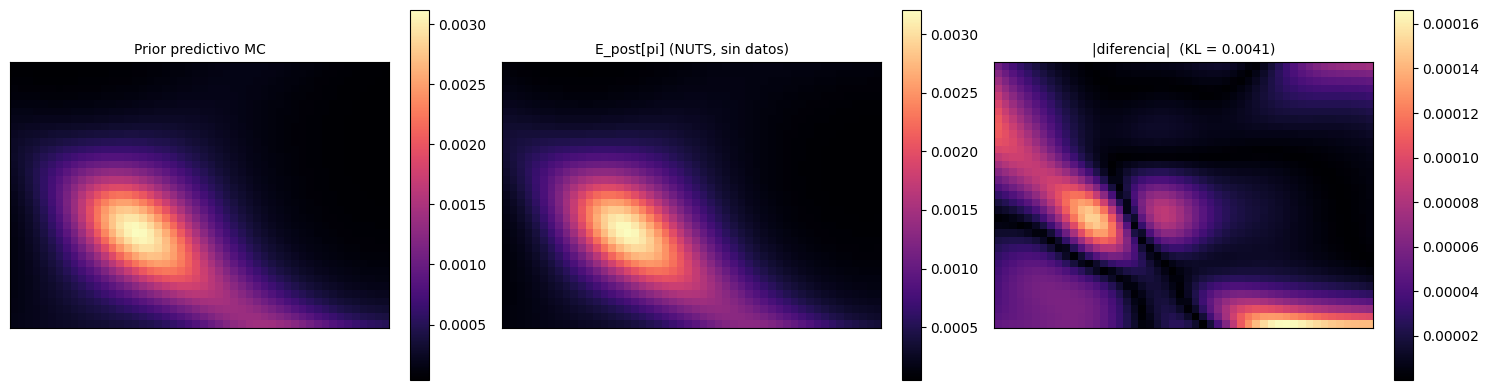

In [3]:
# Comparar E_post[pi] (sin datos) vs prior predictivo MC
mean_pi_post = posterior_pi(idata0)
mc_prior = spec.prior_predictive_pi(grid.x, grid.y, n_samples=800, seed=0)
kl = (mc_prior * np.log(np.clip(mc_prior, 1e-12, None) / np.clip(mean_pi_post, 1e-12, None))).sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title in zip(axes,
                            [mc_prior, mean_pi_post, np.abs(mc_prior - mean_pi_post)],
                            ['Prior predictivo MC', 'E_post[pi] (NUTS, sin datos)',
                             f'|diferencia|  (KL = {kl:.4f})']):
    im = ax.imshow(grid.reshape_2d(vals), origin='lower', cmap='magma',
                   extent=[0, grid.Nx, 0, grid.Ny])
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 2. Arviz: trace plot y posterior marginales de $(\beta, \tau)$

El plot de izquierda muestra la distribución posterior marginal de cada parámetro. El de derecha, las trazas de las cadenas — buscamos cadenas mezcladas y estacionarias.

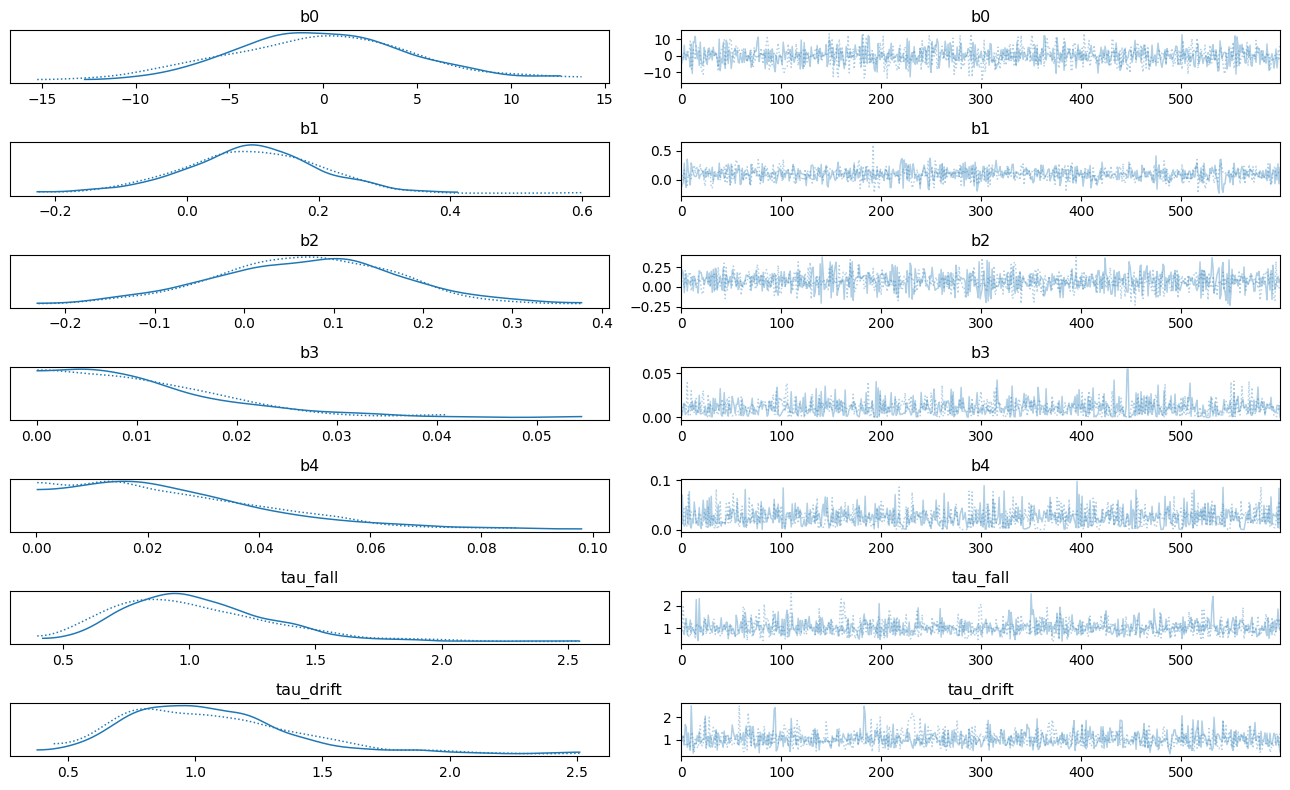

In [4]:
az.plot_trace(idata0, var_names=['b0','b1','b2','b3','b4','tau_fall','tau_drift'],
              compact=True, figsize=(13, 8))
plt.tight_layout(); plt.show()

## 3. Sanity 2 — Inyección de una detección sintética

Forzamos `s_t = 1` en un rectángulo pequeño y reiniciamos MCMC. Esperamos que toda la masa de probabilidad de $Z$ se concentre en el rectángulo. La posterior de $(\beta, \tau)$ se ajustará para que $\pi_j$ tenga su pico dentro de ese rect.

In [5]:
m_synth = MissionRecord(mission_id=1, x_min=12.5, x_max=15.5, y_min=13.5, y_max=16.5,
                         effort=2, n_cells=16, cost=32.0, s_t=1, budget_remaining=198.0)
idata1 = run_mcmc(spec, detector, history=[m_synth], grid=grid,
                  draws=600, tune=600, chains=2, cores=1,
                  progressbar=False, use_cache=True)
diagnostics_summary(idata1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [b0, b1, b2, b3, b4, tau_fall, tau_drift]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b0,0.164,5.020,-9.067,10.368,0.144,0.148,1229.931,752.404,1.003
b1,0.067,0.089,-0.083,0.253,0.004,0.003,593.873,636.768,1.002
b2,0.065,0.094,-0.111,0.247,0.003,0.003,1037.452,819.717,1.001
b3,0.015,0.009,0.001,0.031,0.000,0.000,949.310,489.472,1.002
b4,0.034,0.020,0.001,0.068,0.001,0.001,979.039,376.156,1.003
tau_fall,1.005,0.291,0.516,1.530,0.008,0.010,1323.264,942.987,1.000
tau_drift,1.035,0.309,0.508,1.607,0.010,0.009,878.476,989.301,1.007


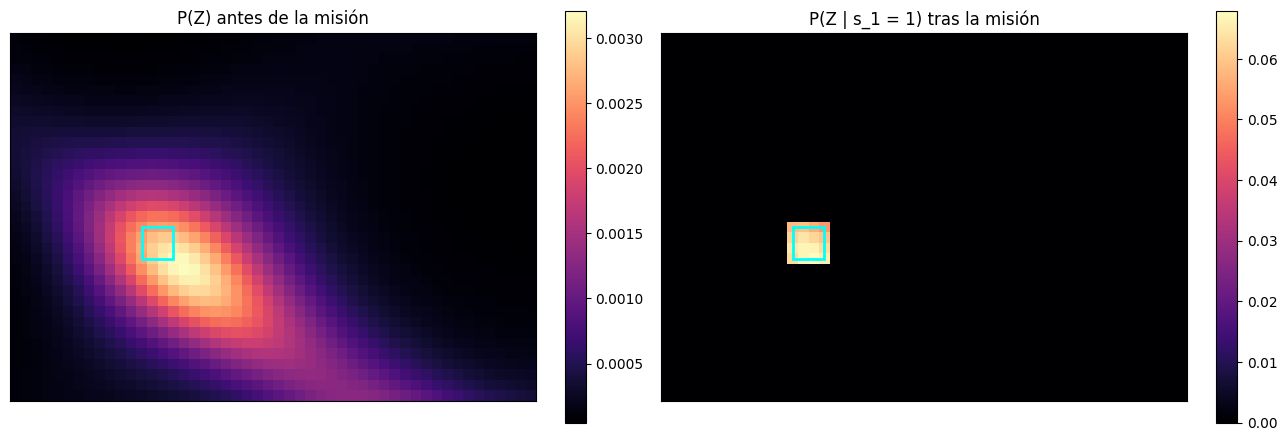

P(Z en rect | s_1=1) = 1.0000  (debería ser ~1)


In [6]:
p_Z_before = posterior_over_Z(idata0, grid, detector, history=[])
p_Z_after = posterior_over_Z(idata1, grid, detector, history=[m_synth])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, vals, title in zip(axes, [p_Z_before, p_Z_after],
                            ['P(Z) antes de la misión', 'P(Z | s_1 = 1) tras la misión']):
    im = ax.imshow(grid.reshape_2d(vals), origin='lower', cmap='magma',
                   extent=[0, grid.Nx, 0, grid.Ny])
    # marcar el rectángulo de la misión
    rect = plt.Rectangle((m_synth.x_min, m_synth.y_min),
                          m_synth.x_max - m_synth.x_min,
                          m_synth.y_max - m_synth.y_min,
                          edgecolor='cyan', facecolor='none', lw=2)
    ax.add_patch(rect)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

covered = grid.coverage_mask(m_synth.x_min, m_synth.x_max, m_synth.y_min, m_synth.y_max)
print(f'P(Z en rect | s_1=1) = {p_Z_after[covered].sum():.4f}  (debería ser ~1)')

## 4. Sanity 3 — Una no-detección $s_t = 0$

Si la misión devuelve $s_t = 0$ la posterior de $Z$ debe *desplazarse fuera* del rectángulo (al menos parcialmente). Cuanto más fuerte el detector y mayor el effort, más fuerte el desplazamiento.

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [b0, b1, b2, b3, b4, tau_fall, tau_drift]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 11 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


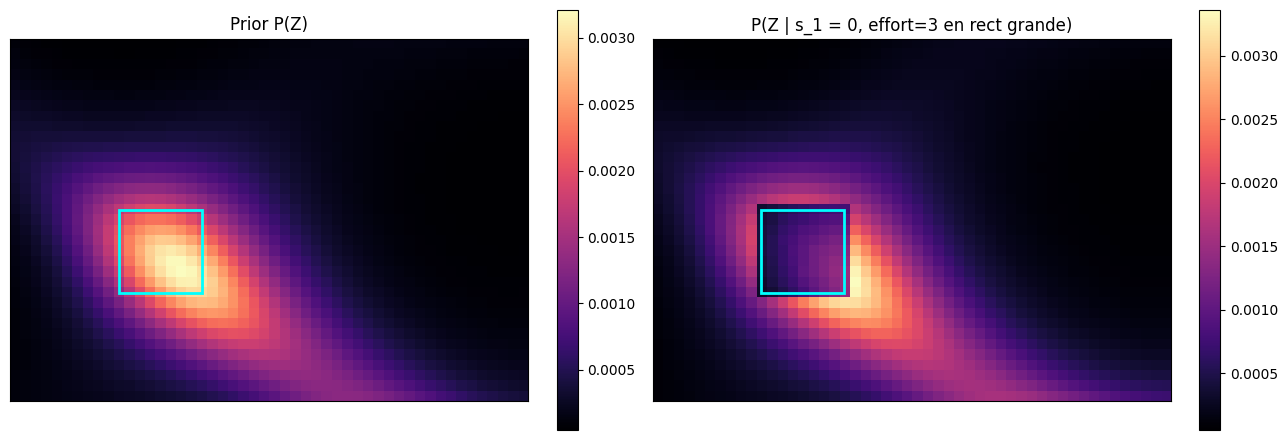

P(Z en rect) antes = 0.199
P(Z en rect) después = 0.068


In [7]:
m_neg = MissionRecord(mission_id=1, x_min=10.5, x_max=18.5, y_min=10.5, y_max=18.5,
                       effort=3, n_cells=81, cost=243.0, s_t=0, budget_remaining=0.0)
idata_neg = run_mcmc(spec, detector, history=[m_neg], grid=grid,
                     draws=600, tune=600, chains=2, cores=1,
                     progressbar=False, use_cache=True)
p_Z_neg = posterior_over_Z(idata_neg, grid, detector, history=[m_neg])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, vals, title in zip(axes, [p_Z_before, p_Z_neg],
                            ['Prior P(Z)', 'P(Z | s_1 = 0, effort=3 en rect grande)']):
    im = ax.imshow(grid.reshape_2d(vals), origin='lower', cmap='magma',
                   extent=[0, grid.Nx, 0, grid.Ny])
    rect = plt.Rectangle((m_neg.x_min, m_neg.y_min),
                          m_neg.x_max - m_neg.x_min, m_neg.y_max - m_neg.y_min,
                          edgecolor='cyan', facecolor='none', lw=2)
    ax.add_patch(rect)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print(f'P(Z en rect) antes = {p_Z_before[grid.coverage_mask(m_neg.x_min,m_neg.x_max,m_neg.y_min,m_neg.y_max)].sum():.3f}')
print(f'P(Z en rect) después = {p_Z_neg[grid.coverage_mask(m_neg.x_min,m_neg.x_max,m_neg.y_min,m_neg.y_max)].sum():.3f}')

## 5. ¿Cómo cambian los coeficientes con datos?

Comparamos las posteriores marginales de $(\beta, \tau)$ antes y después de la observación. Esto demuestra el sentido completo del enfoque jerárquico: **no solo actualizamos donde está Z, actualizamos nuestras creencias sobre la física**.

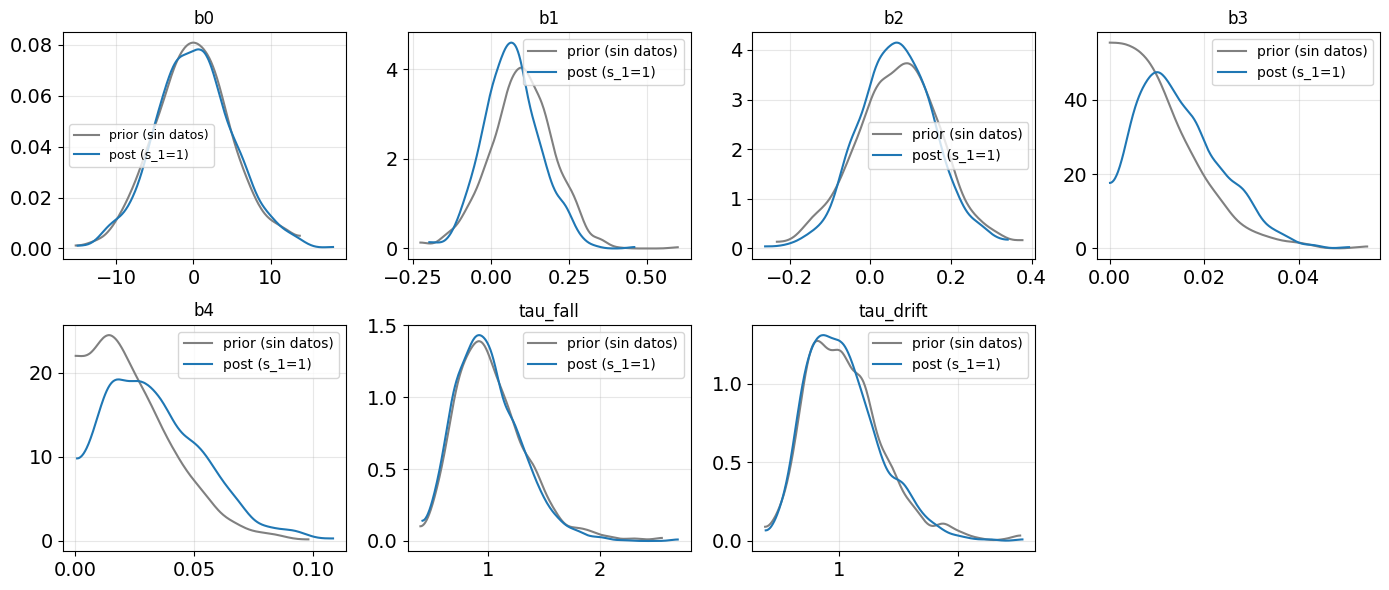

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, var in zip(axes.flat, ['b0','b1','b2','b3','b4','tau_fall','tau_drift']):
    az.plot_dist(idata0.posterior[var].values.flatten(), ax=ax, color='gray', label='prior (sin datos)')
    az.plot_dist(idata1.posterior[var].values.flatten(), ax=ax, color='C0', label='post (s_1=1)')
    ax.set_title(var); ax.grid(alpha=0.3)
axes.flat[-1].axis('off')
axes.flat[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. Summary del posterior sobre Z

Para proponer la próxima misión necesitamos resumir el posterior actual: dónde está el pico, cuánta masa hay, cuál es la entropía (¿estamos seguros o no?).

In [9]:
for label, post in [('antes (prior)', p_Z_before), ('tras s_t=1', p_Z_after), ('tras s_t=0', p_Z_neg)]:
    s = summarise_posterior_over_Z(post, grid, k_top=3)
    print(f'{label:18s}  argmax cell {s["argmax_cell"]} (x,y)={s["argmax_xy"]}, max P={s["max_prob"]:.3f}, entropy={s["entropy_nats"]:.2f} nats')

antes (prior)       argmax cell 616 (x,y)=(16.5, 12.5), max P=0.003, entropy=6.91 nats
tras s_t=1          argmax cell 664 (x,y)=(14.5, 13.5), max P=0.068, entropy=2.77 nats
tras s_t=0          argmax cell 569 (x,y)=(19.5, 11.5), max P=0.003, entropy=6.99 nats


## 7. Siguiente

Con la posterior sobre $Z$ en la mano, el notebook [`04_pipeline_and_strategy.ipynb`](04_pipeline_and_strategy.ipynb) usa el simulador para correr una campaña completa: planta el objeto, propone misiones óptimas con `strategies/next_mission.py`, registra los outcomes y actualiza la posterior tras cada paso.